<a href="https://colab.research.google.com/github/MatiasO2312/Aprendizaje-Automatico/blob/main/Clase%208/Clase%208%20-%20AA%20-%20Matias%20Oroz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CLASE 8 — Aprendizaje No Supervisado: K-Means Clustering
# Dataset: Segmentación de Clientes


In [19]:
# Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Estilo de gráficos
sns.set_theme(style="whitegrid")

In [20]:
# Carga del dataset
df = pd.read_csv('/content/sample_data/dataset_segmentacion_clientes.csv')
print('Shape:', df.shape)
df.head()

Shape: (700, 7)


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522


In [21]:
# Exploración general
print("=== Tipos de datos ===")
print(df.dtypes)
print("\n=== Estadísticas descriptivas ===")
df.describe()

=== Tipos de datos ===
purchase_freq_month     float64
avg_basket_usd          float64
time_on_site_min        float64
discount_sensitivity    float64
returns_rate            float64
noise_gauss             float64
noise_uniform           float64
dtype: object

=== Estadísticas descriptivas ===


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,5.875724,248.173491,16.784799,0.425083,0.337194,0.023814,-0.010523
std,4.471079,154.904372,12.914111,0.431467,0.356623,1.009325,1.679810
min,0.100000,86.994100,3.163206,0.000000,0.000000,-3.566175,-2.993585
25%,2.278418,90.766945,6.603950,0.000000,0.000000,-0.654168,-1.424864
50%,4.134580,180.223799,9.974407,0.296475,0.165559,0.076845,0.013148
75%,11.214919,449.719033,34.341360,1.000000,0.800000,0.728304,1.407124
max,14.603388,452.973583,38.348156,1.000000,0.800000,2.863317,2.995020


In [22]:
# Valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
purchase_freq_month     0
avg_basket_usd          0
time_on_site_min        0
discount_sensitivity    0
returns_rate            0
noise_gauss             0
noise_uniform           0
dtype: int64


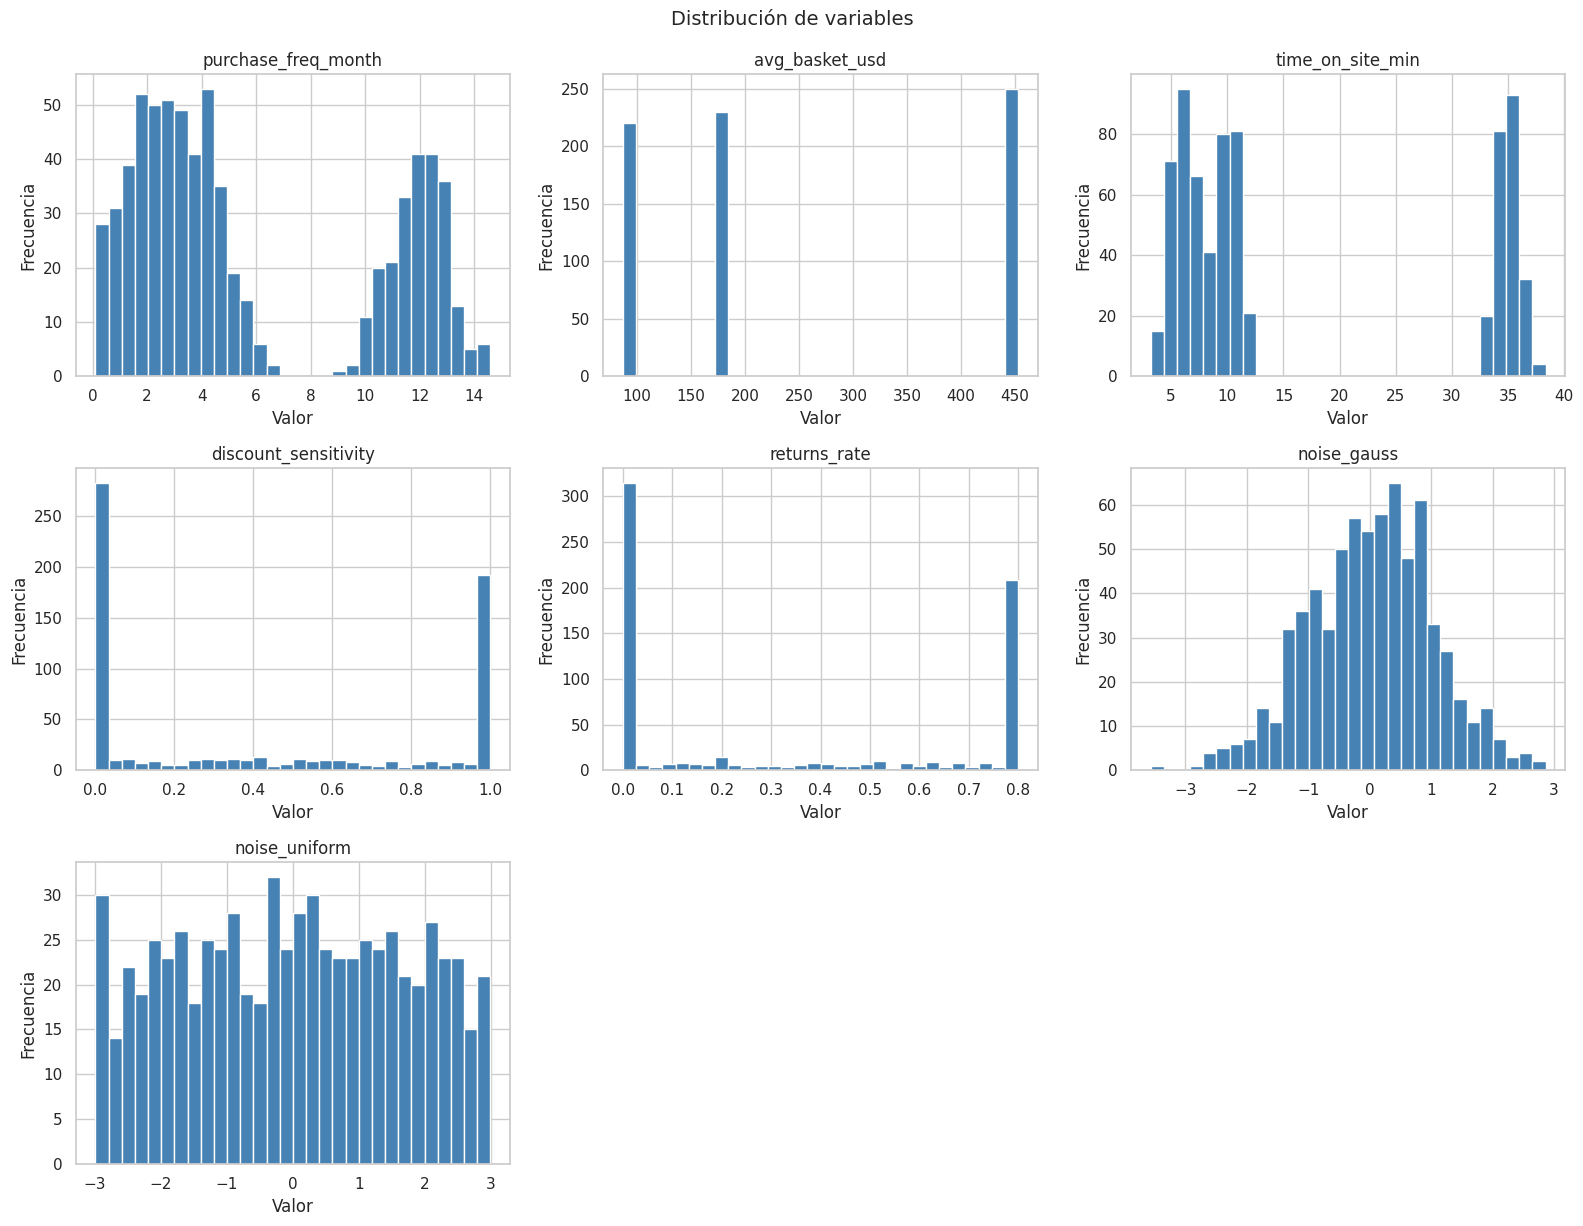

In [23]:
# Visualización de distribuciones
fig, axes = plt.subplots(3, 3, figsize=(16, 12)) # Changed to 3 rows, 3 columns
cols = df.columns.tolist()

for i, col in enumerate(cols):
    ax = axes[i // 3][i % 3]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")

# Remove any unused subplots
for j in range(len(cols), 3 * 3): # Iterate from the number of columns to the total number of subplots
    fig.delaxes(axes[j // 3][j % 3])

plt.tight_layout()
plt.suptitle("Distribución de variables", y=1.02, fontsize=14)
plt.show()

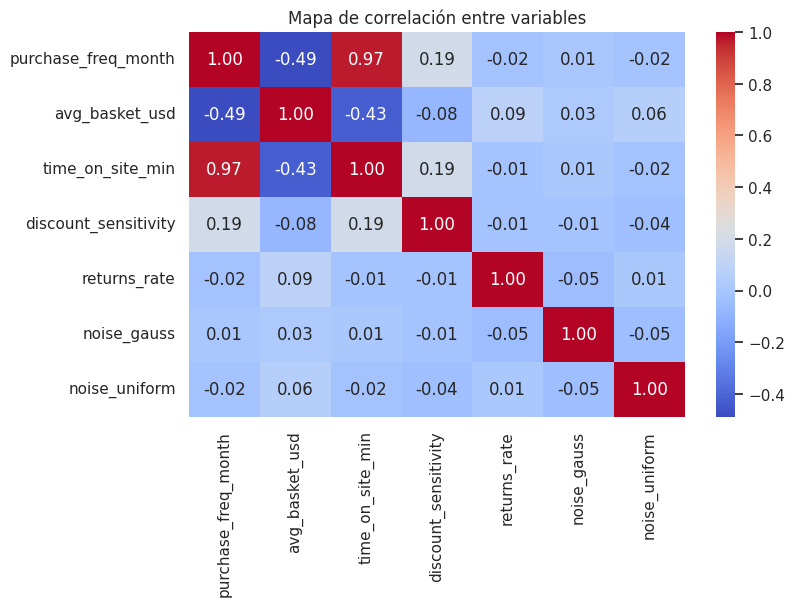

In [24]:
# Correlación entre variables
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Mapa de correlación entre variables")
plt.show()

In [25]:
# Escalado de variables
# K-Means trabaja con distancias, por lo tanto es fundamental escalar las variables antes de aplicar el modelo
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

print("Datos escalados — primeras filas:")
df_scaled.head()

Datos escalados — primeras filas:


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,1.181048,-0.432012,1.300224,1.333423,1.298671,-1.814779,-1.493130
1,1.382696,-0.449219,1.444979,0.834706,-0.946196,0.616014,1.266514
2,-0.822026,1.305039,-0.755841,1.097540,-0.946196,-0.070613,-0.425143
3,-0.367604,-1.028253,-0.461093,-0.985910,1.298671,0.870397,-1.765451
4,-0.930849,1.302382,-0.738500,-0.985910,-0.936996,0.359109,1.450632


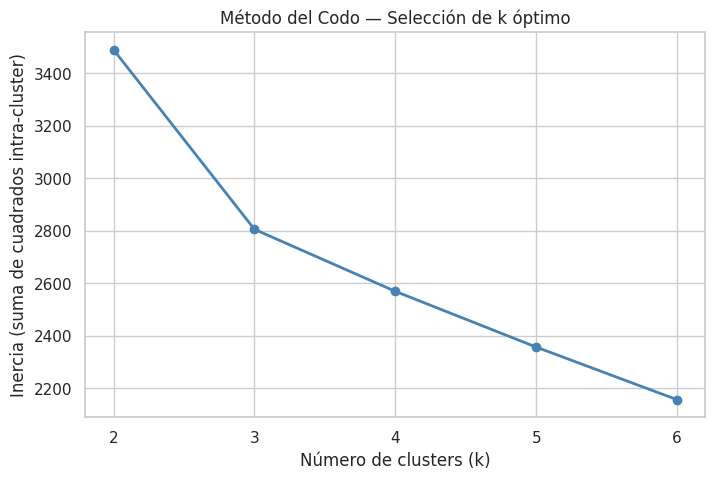

Inercias: {2: 3488.6040241323935, 3: 2804.9011925882887, 4: 2568.762840206325, 5: 2356.5193838941263, 6: 2156.182294932023}


In [26]:
# Método del codo para determinar k óptimo
inercias = []
rango_k = range(2, 7)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inercias.append(kmeans.inertia_)

# Gráfico del codo
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercias, marker='o', color='steelblue', linewidth=2)
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (suma de cuadrados intra-cluster)")
plt.title("Método del Codo — Selección de k óptimo")
plt.xticks(rango_k)
plt.grid(True)
plt.show()

print("Inercias:", dict(zip(rango_k, inercias)))

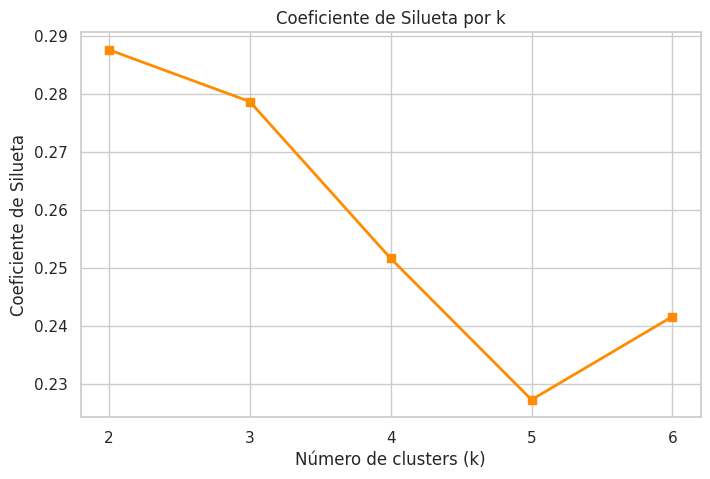

Siluetas: {2: np.float64(0.28768015179503453), 3: np.float64(0.27874173864643237), 4: np.float64(0.25165167753620343), 5: np.float64(0.22723678557896643), 6: np.float64(0.2416129684783634)}


In [27]:
# Coeficiente de silueta como validación adicional
siluetas = []

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    siluetas.append(score)

plt.figure(figsize=(8, 5))
plt.plot(rango_k, siluetas, marker='s', color='darkorange', linewidth=2)
plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de Silueta")
plt.title("Coeficiente de Silueta por k")
plt.xticks(rango_k)
plt.grid(True)
plt.show()

print("Siluetas:", dict(zip(rango_k, siluetas)))

In [28]:
# Entrenamiento del modelo final con k=3
k_optimo = 3

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(df_scaled)

print(f"Modelo entrenado con k={k_optimo}")
print("Distribución de clientes por cluster:")
print(df['cluster'].value_counts().sort_index())

Modelo entrenado con k=3
Distribución de clientes por cluster:
cluster
0    230
1    220
2    250
Name: count, dtype: int64


In [29]:
# Análisis de centroides (perfiles de cluster)
centroides = df.groupby('cluster').mean().round(3)
print("=== Centroides por cluster (valores originales) ===")
centroides

=== Centroides por cluster (valores originales) ===


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
cluster,,,,,,,
0,11.961,179.999,35.022,0.542,0.332,0.047,-0.040
1,4.092,89.958,10.004,0.379,0.299,-0.032,-0.132
2,1.847,450.124,5.974,0.358,0.375,0.052,0.123


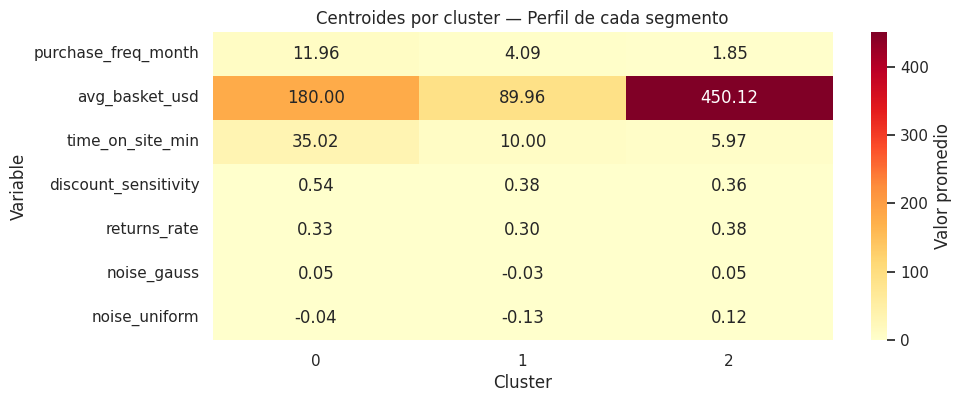

In [30]:
# Visualización de centroides como heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(centroides.T, annot=True, cmap='YlOrRd', fmt='.2f',
            cbar_kws={'label': 'Valor promedio'})
plt.title("Centroides por cluster — Perfil de cada segmento")
plt.xlabel("Cluster")
plt.ylabel("Variable")
plt.show()

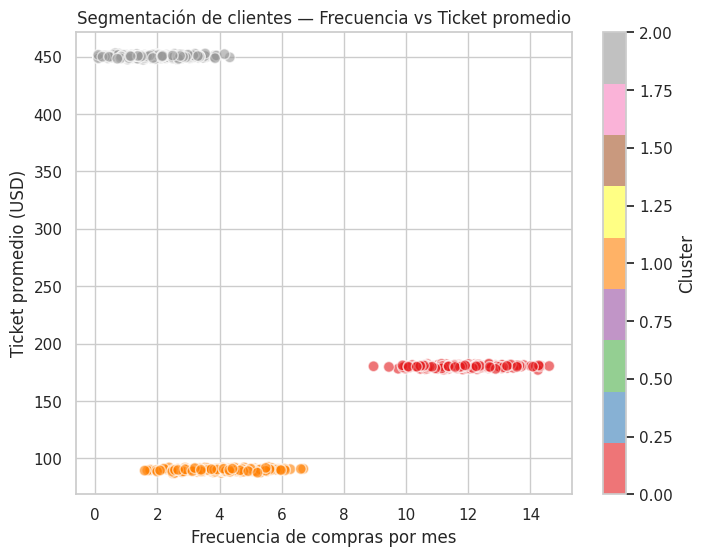

In [31]:
# Visualización scatter: frecuencia vs ticket promedio
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df['purchase_freq_month'],
    df['avg_basket_usd'],
    c=df['cluster'],
    cmap='Set1',
    alpha=0.6,
    edgecolors='white',
    s=60
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel("Frecuencia de compras por mes")
plt.ylabel("Ticket promedio (USD)")
plt.title("Segmentación de clientes — Frecuencia vs Ticket promedio")
plt.show()

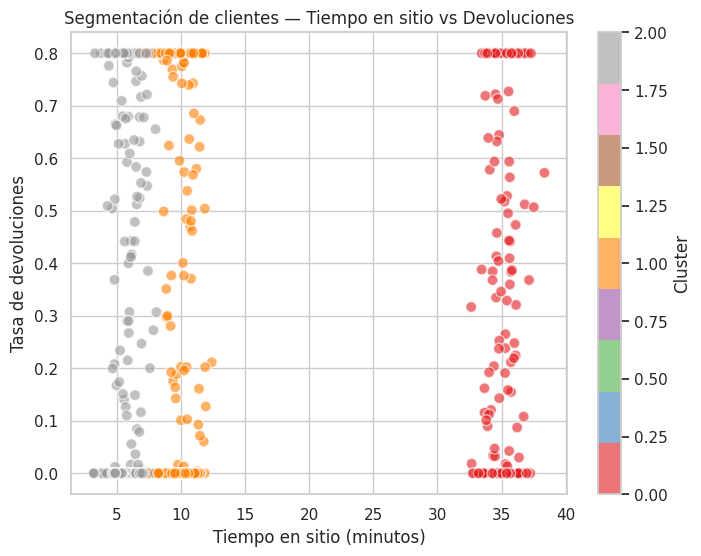

In [32]:
# Visualización scatter: tiempo en sitio vs tasa de devoluciones
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df['time_on_site_min'],
    df['returns_rate'],
    c=df['cluster'],
    cmap='Set1',
    alpha=0.6,
    edgecolors='white',
    s=60
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel("Tiempo en sitio (minutos)")
plt.ylabel("Tasa de devoluciones")
plt.title("Segmentación de clientes — Tiempo en sitio vs Devoluciones")
plt.show()

## Conclusiones

A partir del análisis de clustering con K-Means aplicado al dataset de segmentación de clientes, se identificaron **tres segmentos diferenciados** con perfiles de comportamiento claramente distintos.

Para determinar el valor óptimo de k se utilizó el método del codo, donde se observa que la mayor reducción de inercia ocurre entre k=2 y k=3 (de 3488 a 2804), mientras que a partir de k=4 la mejora se vuelve marginal. El coeficiente de silueta también acompaña esta elección, con valores similares entre k=2 y k=3 pero siendo k=3 el que ofrece mayor riqueza de información para el análisis.

El **Cluster 0** agrupa a los clientes más activos del sitio, compran cerca de 12 veces por mes con un ticket promedio de $180 y pasan en promedio 35 minutos en su compra, parece que se toman su tiempo. Además, presentan la mayor sensibilidad a los descuentos, por lo que serían los candidatos ideales para campañas de promociones y programas de fidelización.

El **Cluster 1** representa a compradores más ocasionales, con una frecuencia de aproximadamente 4 compras por mes y el ticket más bajo del dataset ($90). Pasan poco tiempo en el sitio y no reaccionan especialmente ante los descuentos. Este grupo podría beneficiarse de estrategias de reactivación y propuestas de cross-selling para elevar su ticket promedio.

El **Cluster 2** es el más interesante desde el punto de vista comercial: son los clientes que menos compran (menos de 2 veces por mes) pero tienen el ticket más alto del dataset, cercano a los $450. Pasan muy poco tiempo en el sitio antes de comprar, lo que indica que cuando ingresan ya tienen claro lo que quieren. Su baja sensibilidad a los descuentos sugiere que no necesitan incentivos económicos para comprar, por lo que la estrategia más adecuada sería el upselling, productos exclusivos o un programa de atención preferencial.

Por último, cabe destacar que el dataset incluía dos variables de ruido (noise_gauss y noise_uniform). Los valores de los centroides para ambas columnas se encuentran muy cercanos a cero en los tres clusters, lo que confirma que el modelo no encontró patrones en ellas y las descartó de forma efectiva al momento de agrupar.